# Mean Altitude Test
This code is written to obtain an overall view of the most common altitude parameters observed in the downloaded LFBO aircraft trajectory data. This data will be useful in integrating the weather data into an H3-grid, by giving information on which points of altitude are most important for downloading weather data for, and in essence is worth interpolating.

Total trajectory points: 4048210
Altitude range: -2202952 to 210247 ft
Mean: 24321 ft | Median: 28525 ft

--- Percentiles ---
  5th percentile: 3075 ft
  25th percentile: 14550 ft
  50th percentile: 28525 ft
  75th percentile: 34975 ft
  90th percentile: 37000 ft
  95th percentile: 39000 ft
  99th percentile: 40325 ft

--- Fraction of points nearest each pressure level ---
  1000 hPa (~  364 ft):   0.9%
   925 hPa (~ 2500 ft):   5.6%
   850 hPa (~ 4781 ft):   7.2%
   700 hPa (~ 9882 ft):  10.7%
   500 hPa (~18289 ft):  11.6%
   400 hPa (~23574 ft):  10.1%
   300 hPa (~30065 ft):  16.3%
   250 hPa (~33999 ft):  22.9%
   200 hPa (~38662 ft):  14.9%

Saved altitude_distribution.png


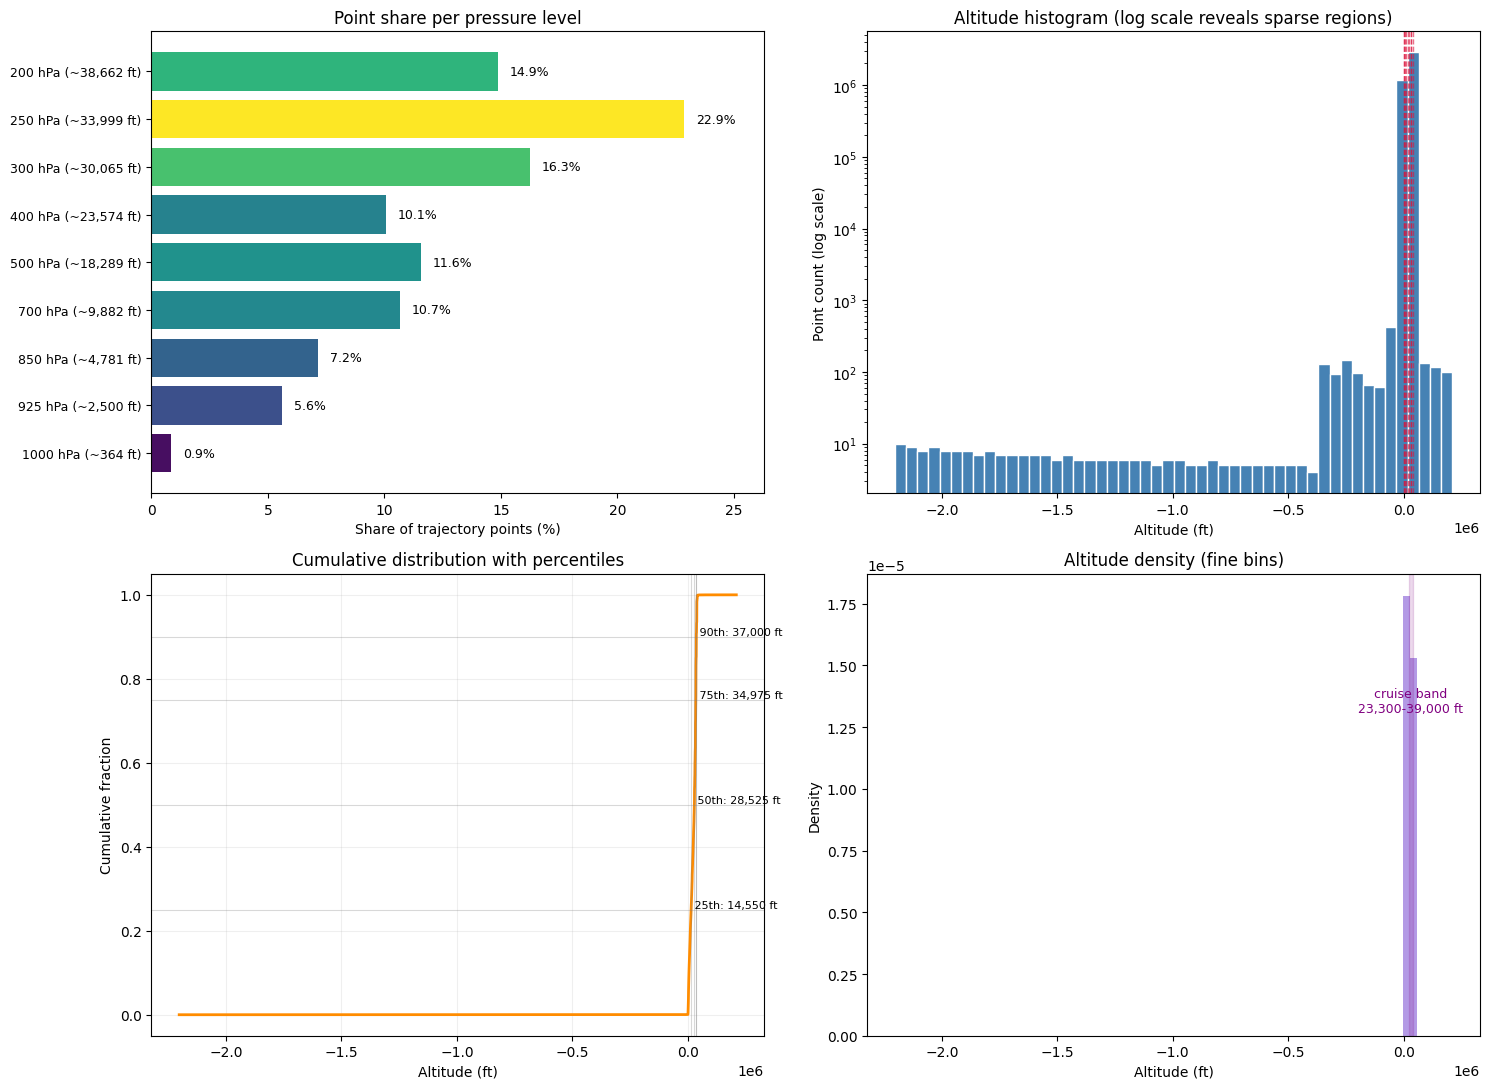

In [1]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

DATA_SOURCE = Path("./src/data/raw")
AIRPORT = "LFBO"

CURRENT_PRESSURE_LEVELS = [200, 250, 300, 400, 500, 700, 850, 925, 1000]
STANDARD_PRESSURE_TO_ALT_FT = {
    1000: 364, 925: 2500, 850: 4781, 700: 9882,
    500: 18289, 400: 23574, 300: 30065, 250: 33999, 200: 38662,
}

def load_altitudes(data_source, airport):
    lf = pl.scan_parquet(
        source=str(Path(data_source) / "**" / "*.parquet"),
        hive_schema={"destination": pl.String, "year": pl.Int64, "month": pl.Int64, "day": pl.Int64},
        hive_partitioning=True,
        cast_options=pl.ScanCastOptions(datetime_cast="nanosecond-downcast"),
    ).filter(pl.col("destination") == airport)
    alts = lf.select(pl.col("altitude").explode().alias("alt")).collect().get_column("alt").to_numpy()
    return alts[~np.isnan(alts)]

def main():
    alts = load_altitudes(DATA_SOURCE, AIRPORT)
    print(f"Total trajectory points: {len(alts)}")
    print(f"Altitude range: {alts.min():.0f} to {alts.max():.0f} ft")
    print(f"Mean: {alts.mean():.0f} ft | Median: {np.median(alts):.0f} ft")

    print("\n--- Percentiles ---")
    for p in [5, 25, 50, 75, 90, 95, 99]:
        print(f"  {p}th percentile: {np.percentile(alts, p):.0f} ft")

    lvl_by_alt = sorted(STANDARD_PRESSURE_TO_ALT_FT.items(), key=lambda kv: kv[1])
    level_alts = [a for _, a in lvl_by_alt]
    edges = [0] + [(level_alts[i] + level_alts[i+1]) / 2 for i in range(len(level_alts)-1)] + [alts.max()+1]
    fracs = []
    print("\n--- Fraction of points nearest each pressure level ---")
    for i, (lvl, lvl_alt) in enumerate(lvl_by_alt):
        f = np.mean((alts >= edges[i]) & (alts < edges[i+1])) * 100
        fracs.append(f)
        print(f"  {lvl:>4} hPa (~{lvl_alt:>5} ft): {f:5.1f}%")

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    ax = axes[0, 0]
    labels = [f"{lvl} hPa (~{alt:,} ft)" for lvl, alt in lvl_by_alt]
    colors = plt.cm.viridis(np.array(fracs) / max(fracs))
    ax.barh(range(len(fracs)), fracs, color=colors)
    ax.set_yticks(range(len(fracs)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Share of trajectory points (%)")
    ax.set_title("Point share per pressure level")
    for i, f in enumerate(fracs):
        ax.text(f + 0.5, i, f"{f:.1f}%", va="center", fontsize=9)
    ax.margins(x=0.15)

    ax = axes[0, 1]
    ax.hist(alts, bins=50, color="steelblue", edgecolor="white")
    ax.set_yscale("log")
    for lvl_alt in STANDARD_PRESSURE_TO_ALT_FT.values():
        ax.axvline(lvl_alt, color="crimson", alpha=0.6, linewidth=1, linestyle="--")
    ax.set_xlabel("Altitude (ft)")
    ax.set_ylabel("Point count (log scale)")
    ax.set_title("Altitude histogram (log scale reveals sparse regions)")

    ax = axes[1, 0]
    sorted_alts = np.sort(alts)
    cum = np.arange(1, len(sorted_alts)+1) / len(sorted_alts)
    ax.plot(sorted_alts, cum, color="darkorange", linewidth=2)
    for p in [25, 50, 75, 90]:
        val = np.percentile(alts, p)
        ax.axhline(p/100, color="gray", alpha=0.3, linewidth=0.8)
        ax.axvline(val, color="gray", alpha=0.3, linewidth=0.8)
        ax.text(val, p/100, f" {p}th: {val:,.0f} ft", fontsize=8, va="bottom")
    ax.set_xlabel("Altitude (ft)")
    ax.set_ylabel("Cumulative fraction")
    ax.set_title("Cumulative distribution with percentiles")
    ax.grid(alpha=0.2)

    ax = axes[1, 1]
    ax.hist(alts, bins=80, color="mediumpurple", edgecolor="none", density=True, alpha=0.7)
    ax.set_xlabel("Altitude (ft)")
    ax.set_ylabel("Density")
    ax.set_title("Altitude density (fine bins)")
    peak_lo, peak_hi = np.percentile(alts, 40), np.percentile(alts, 95)
    ax.axvspan(peak_lo, peak_hi, alpha=0.15, color="purple")
    ax.text((peak_lo+peak_hi)/2, ax.get_ylim()[1]*0.7,
            f"cruise band\n{peak_lo:,.0f}-{peak_hi:,.0f} ft",
            ha="center", fontsize=9, color="purple")

    plt.tight_layout()
    plt.savefig("altitude_distribution.png", dpi=110)
    print("\nSaved altitude_distribution.png")

if __name__ == "__main__":
    main()